# Titanic Survival Prediction

**Project Analisis & Klasifikasi Machine Learning**

Project ini menganalisis dataset penumpang kapal Titanic dan membangun model machine learning untuk memprediksi kemungkinan seorang penumpang selamat berdasarkan profilnya (usia, jenis kelamin, kelas tiket, dll).

---

##  Tujuan Project
1. Melakukan eksplorasi data (EDA) untuk memahami pola dalam dataset
2. Membersihkan dan mempersiapkan data untuk modeling
3. Membangun model klasifikasi untuk memprediksi keselamatan penumpang
4. Mengevaluasi performa model menggunakan metrik yang sesuai

##  Tools & Library
- **Python 3** — bahasa pemrograman utama
- **Pandas** — manipulasi & analisis data
- **NumPy** — komputasi numerik
- **Matplotlib & Seaborn** — visualisasi data
- **Scikit-learn** — machine learning

##  Tentang Dataset
Dataset Titanic berisi informasi 891 penumpang kapal Titanic yang tenggelam pada 15 April 1912. Setiap baris mewakili satu penumpang dengan atribut seperti usia, jenis kelamin, kelas kabin, dan status keselamatan.

## 1️ Import Library

Pertama, kita import semua library yang akan digunakan.

In [1]:
# Library untuk manipulasi data
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library scikit-learn untuk machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Pengaturan tampilan
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

# Menonaktifkan warning agar output lebih rapi
import warnings
warnings.filterwarnings('ignore')

print(" Semua library berhasil di-import!")

 Semua library berhasil di-import!


## 2️ Load Dataset

Kita menggunakan dataset Titanic yang sudah tersedia di library Seaborn, jadi tidak perlu download manual.

In [2]:
# Memuat dataset Titanic dari seaborn
df = sns.load_dataset('titanic')

# Menampilkan 5 baris pertama untuk melihat struktur data
print(f"Ukuran dataset: {df.shape[0]} baris dan {df.shape[1]} kolom\n")
df.head()

Ukuran dataset: 891 baris dan 15 kolom



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3️ Exploratory Data Analysis (EDA)

Sebelum membangun model, kita perlu memahami data terlebih dahulu.

### 3.1 Informasi Umum Dataset

In [3]:
# Melihat informasi tipe data dan jumlah missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
# Statistik deskriptif untuk kolom numerik
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Penjelasan kolom:**
- `survived` — 0 = tidak selamat, 1 = selamat (TARGET yang akan diprediksi)
- `pclass` — kelas tiket (1 = kelas atas, 2 = menengah, 3 = ekonomi)
- `sex` — jenis kelamin
- `age` — usia penumpang
- `sibsp` — jumlah saudara/pasangan yang ikut
- `parch` — jumlah orang tua/anak yang ikut
- `fare` — harga tiket
- `embarked` — pelabuhan keberangkatan (S=Southampton, C=Cherbourg, Q=Queenstown)
- `class`, `who`, `adult_male`, `deck`, `embark_town`, `alive`, `alone` — kolom turunan

### 3.2 Cek Missing Values

Penting untuk mengetahui kolom mana yang memiliki data kosong.

In [5]:
# Menghitung jumlah dan persentase missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_percent.round(2)
})

# Hanya tampilkan kolom yang punya missing values
missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)

,Jumlah Missing,Persentase (%)
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


**Observasi:**
- Kolom `deck` memiliki ~77% data kosong → akan kita drop
- Kolom `age` memiliki ~20% data kosong → akan kita isi dengan median
- Kolom `embarked` & `embark_town` memiliki sedikit missing → akan kita isi dengan modus

### 3.3 Visualisasi Data

#### Berapa banyak yang selamat vs tidak selamat?

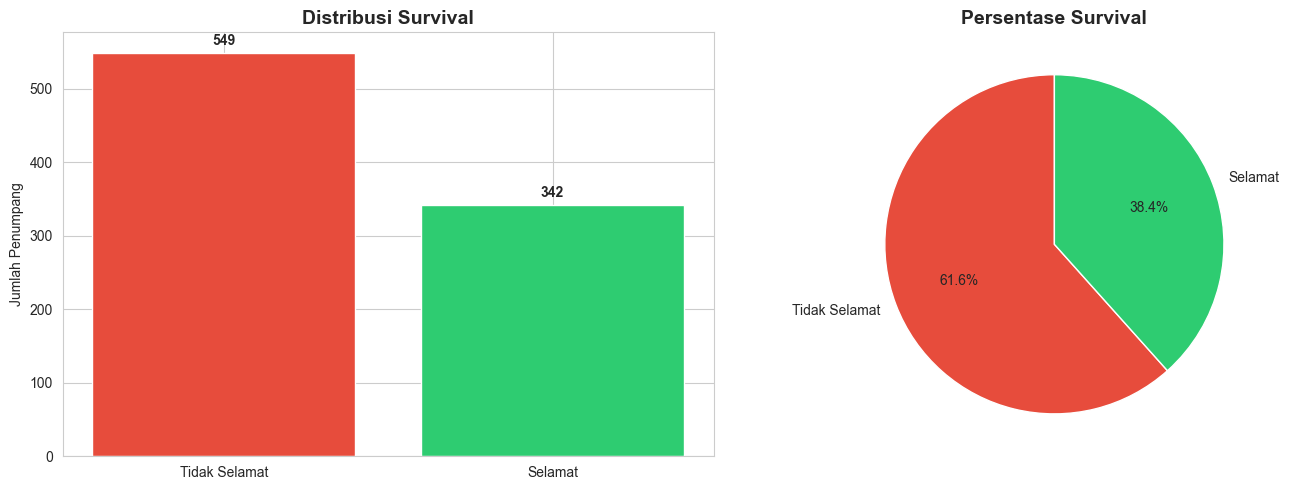


Total penumpang: 891
Selamat: 342 (38.4%)
Tidak selamat: 549 (61.6%)


In [6]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
survival_counts = df['survived'].value_counts()
axes[0].bar(['Tidak Selamat', 'Selamat'], survival_counts.values,
            color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Distribusi Survival', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Penumpang')
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(survival_counts.values,
            labels=['Tidak Selamat', 'Selamat'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Persentase Survival', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nTotal penumpang: {len(df)}")
print(f"Selamat: {survival_counts[1]} ({survival_counts[1]/len(df)*100:.1f}%)")
print(f"Tidak selamat: {survival_counts[0]} ({survival_counts[0]/len(df)*100:.1f}%)")

#### Apakah jenis kelamin berpengaruh terhadap keselamatan?

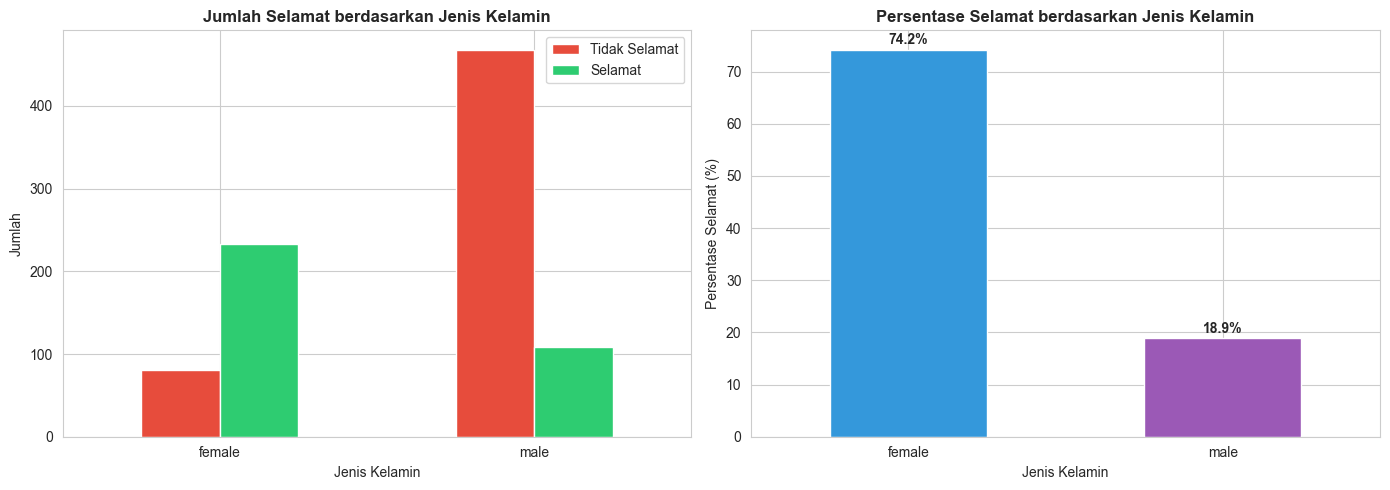


💡 Insight: Wanita memiliki tingkat keselamatan jauh lebih tinggi dibanding pria,
   sesuai dengan kebijakan 'women and children first' saat evakuasi.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Crosstab: jumlah selamat berdasarkan gender
sex_survival = pd.crosstab(df['sex'], df['survived'])
sex_survival.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Jumlah Selamat berdasarkan Jenis Kelamin', fontweight='bold')
axes[0].set_xlabel('Jenis Kelamin')
axes[0].set_ylabel('Jumlah')
axes[0].legend(['Tidak Selamat', 'Selamat'])
axes[0].tick_params(axis='x', rotation=0)

# Persentase selamat
survival_rate = df.groupby('sex')['survived'].mean() * 100
survival_rate.plot(kind='bar', ax=axes[1], color=['#3498db', '#9b59b6'])
axes[1].set_title('Persentase Selamat berdasarkan Jenis Kelamin', fontweight='bold')
axes[1].set_xlabel('Jenis Kelamin')
axes[1].set_ylabel('Persentase Selamat (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(survival_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Wanita memiliki tingkat keselamatan jauh lebih tinggi dibanding pria,")
print("   sesuai dengan kebijakan 'women and children first' saat evakuasi.")

#### Apakah kelas tiket berpengaruh?

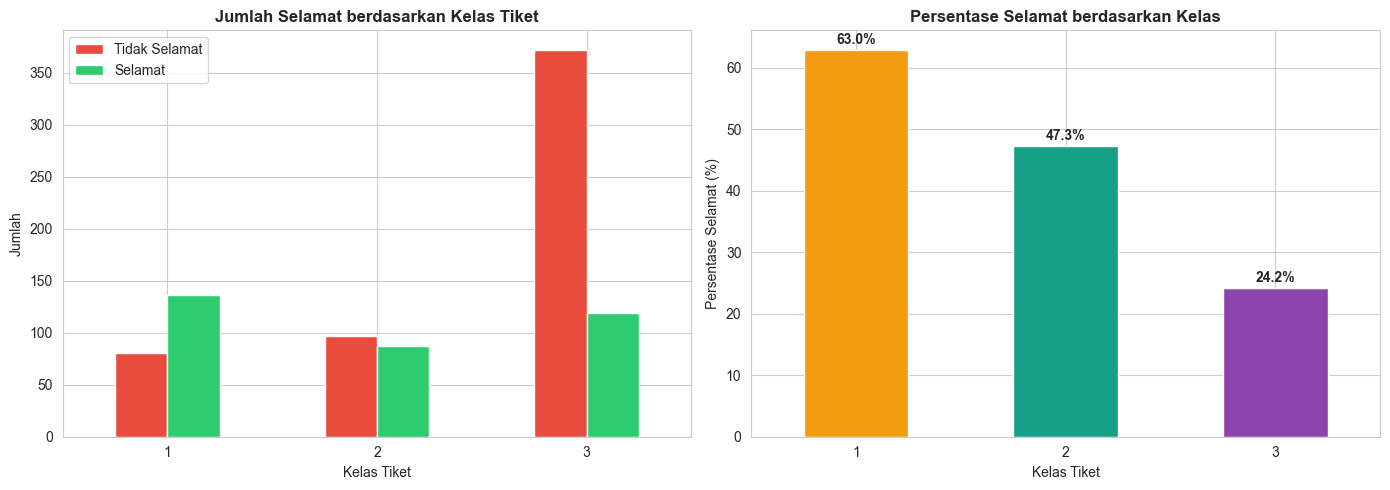


💡 Insight: Penumpang kelas 1 (kelas atas) memiliki tingkat keselamatan tertinggi,
   sedangkan kelas 3 (ekonomi) memiliki tingkat keselamatan terendah.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi berdasarkan kelas
class_survival = pd.crosstab(df['pclass'], df['survived'])
class_survival.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Jumlah Selamat berdasarkan Kelas Tiket', fontweight='bold')
axes[0].set_xlabel('Kelas Tiket')
axes[0].set_ylabel('Jumlah')
axes[0].legend(['Tidak Selamat', 'Selamat'])
axes[0].tick_params(axis='x', rotation=0)

# Persentase
class_rate = df.groupby('pclass')['survived'].mean() * 100
class_rate.plot(kind='bar', ax=axes[1], color=['#f39c12', '#16a085', '#8e44ad'])
axes[1].set_title('Persentase Selamat berdasarkan Kelas', fontweight='bold')
axes[1].set_xlabel('Kelas Tiket')
axes[1].set_ylabel('Persentase Selamat (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(class_rate.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Insight: Penumpang kelas 1 (kelas atas) memiliki tingkat keselamatan tertinggi,")
print("   sedangkan kelas 3 (ekonomi) memiliki tingkat keselamatan terendah.")

#### Bagaimana distribusi usia penumpang?

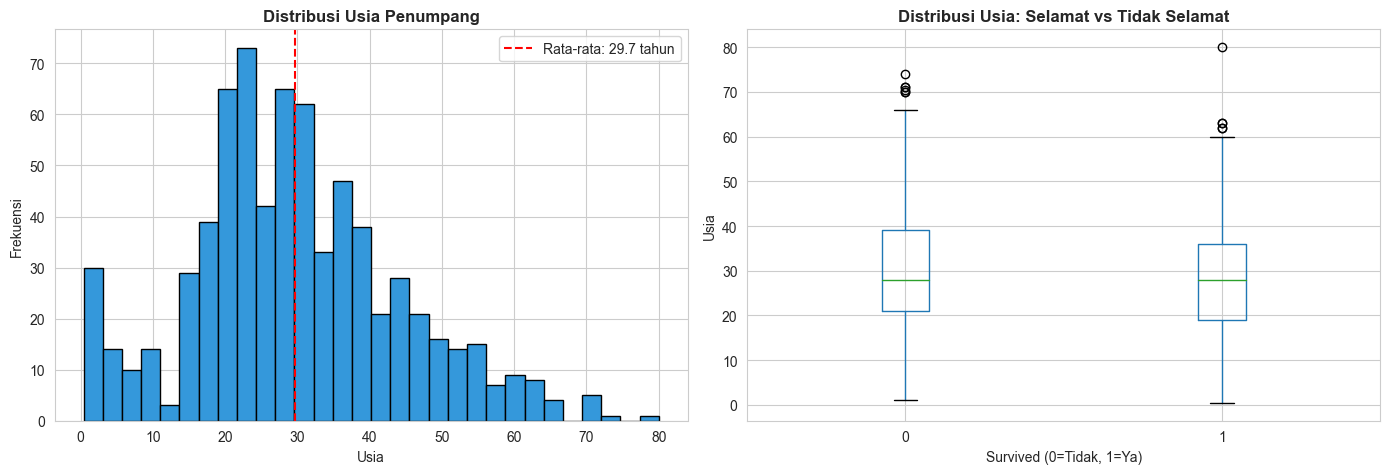

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram usia
df['age'].hist(bins=30, ax=axes[0], color='#3498db', edgecolor='black')
axes[0].set_title('Distribusi Usia Penumpang', fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--',
                label=f'Rata-rata: {df["age"].mean():.1f} tahun')
axes[0].legend()

# Boxplot usia berdasarkan survival
df.boxplot(column='age', by='survived', ax=axes[1])
axes[1].set_title('Distribusi Usia: Selamat vs Tidak Selamat', fontweight='bold')
axes[1].set_xlabel('Survived (0=Tidak, 1=Ya)')
axes[1].set_ylabel('Usia')
plt.suptitle('')

plt.tight_layout()
plt.show()

#### Korelasi antar fitur numerik

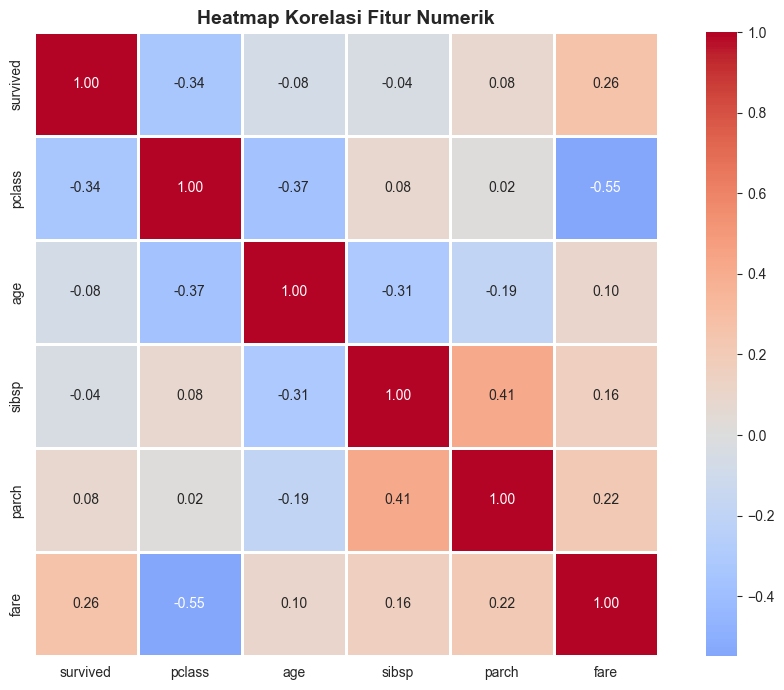

In [10]:
# Heatmap korelasi
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4️ Data Preprocessing

Sekarang kita siapkan data untuk dimasukkan ke model machine learning. Tahapannya:
1. Pilih fitur yang relevan
2. Tangani missing values
3. Konversi data kategorikal ke numerik (encoding)

In [11]:
# Buat copy dataset agar data asli tetap aman
data = df.copy()

# Pilih kolom yang akan digunakan untuk modeling
selected_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
data = data[selected_features + ['survived']]

print("Kolom yang dipilih untuk modeling:")
print(data.columns.tolist())
data.head()

Kolom yang dipilih untuk modeling:
['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


### 4.1 Menangani Missing Values

In [12]:
# Cek missing values sebelum dibersihkan
print("Missing values SEBELUM cleaning:")
print(data.isnull().sum())
print()

# Isi missing values pada kolom 'age' dengan median
# (median lebih robust terhadap outlier dibanding mean)
data['age'] = data['age'].fillna(data['age'].median())

# Isi missing values pada kolom 'embarked' dengan modus (nilai paling sering)
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])

print("Missing values SETELAH cleaning:")
print(data.isnull().sum())

Missing values SEBELUM cleaning:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Missing values SETELAH cleaning:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


### 4.2 Encoding Data Kategorikal

Model machine learning hanya bisa memproses angka, jadi kita perlu mengubah data kategorikal (seperti `sex` dan `embarked`) menjadi numerik.

In [13]:
# Mapping manual untuk kolom 'sex' (binary encoding)
data['sex'] = data['sex'].map({'male': 0, 'female': 1})

# One-hot encoding untuk kolom 'embarked'
# (membuat kolom terpisah untuk setiap nilai unik)
data = pd.get_dummies(data, columns=['embarked'], drop_first=True, dtype=int)

print("Data setelah encoding:")
data.head()

Data setelah encoding:


,pclass,sex,age,sibsp,parch,fare,survived,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,0,0,1
1,1,1,38.0,1,0,71.2833,1,0,0
2,3,1,26.0,0,0,7.9250,1,0,1
3,1,1,35.0,1,0,53.1000,1,0,1
4,3,0,35.0,0,0,8.0500,0,0,1


### 4.3 Memisahkan Fitur (X) dan Target (y)

- **X** = fitur/input yang dipakai untuk prediksi
- **y** = target/output yang ingin diprediksi (survived)

In [14]:
# Pisahkan fitur dan target
X = data.drop('survived', axis=1)
y = data['survived']

print(f"Bentuk X (fitur): {X.shape}")
print(f"Bentuk y (target): {y.shape}")
print(f"\nFitur yang digunakan: {X.columns.tolist()}")

Bentuk X (fitur): (891, 8)
Bentuk y (target): (891,)

Fitur yang digunakan: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']


### 4.4 Split Data: Training & Testing

Kita bagi data menjadi:
- **80% untuk training** — model belajar dari data ini
- **20% untuk testing** — untuk mengukur seberapa baik model bekerja pada data yang belum pernah dilihat

In [15]:
# Split data dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% untuk testing
    random_state=42,      # agar hasil bisa direproduksi
    stratify=y            # menjaga proporsi target seimbang di kedua set
)

print(f"Data training: {X_train.shape[0]} sampel")
print(f"Data testing : {X_test.shape[0]} sampel")

Data training: 712 sampel
Data testing : 179 sampel


### 4.5 Feature Scaling

Beberapa model (seperti Logistic Regression) bekerja lebih baik jika fitur memiliki skala yang sama. Kita normalisasi nilai-nilai fitur agar memiliki mean 0 dan std 1.

In [16]:
# Inisialisasi scaler
scaler = StandardScaler()

# Fit scaler pada data training, lalu transform kedua set
# PENTING: scaler hanya di-fit pada training data untuk menghindari data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(" Feature scaling selesai!")

 Feature scaling selesai!


## 5️ Model Training

Kita akan mencoba **3 algoritma klasifikasi** dan membandingkan performanya:
1. **Logistic Regression** — model linear sederhana, baseline yang baik
2. **Decision Tree** — model berbasis aturan if-else
3. **Random Forest** — kumpulan banyak Decision Tree (ensemble)

In [17]:
# Dictionary untuk menyimpan model dan hasilnya
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
}

results = {}

# Training dan evaluasi setiap model
for name, model in models.items():
    # Training: model belajar dari data training
    if name == 'Logistic Regression':
        # Logistic Regression butuh data yang sudah di-scale
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        # Tree-based model tidak butuh scaling
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Evaluasi: hitung akurasi
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }
    print(f" {name:<22} → Akurasi: {accuracy*100:.2f}%")

 Logistic Regression    → Akurasi: 80.45%
 Decision Tree          → Akurasi: 77.65%
 Random Forest          → Akurasi: 79.33%


## 6️⃣ Evaluasi & Perbandingan Model

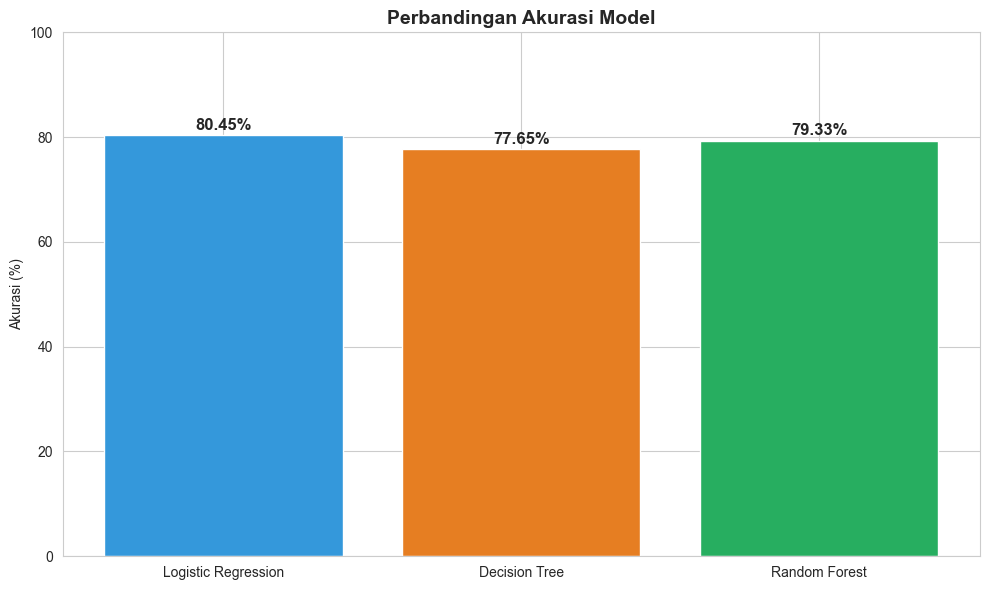


 Model terbaik: Logistic Regression
   Akurasi: 80.45%


In [18]:
# Visualisasi perbandingan akurasi model
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] * 100 for name in model_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies,
               color=['#3498db', '#e67e22', '#27ae60'])
plt.title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
plt.ylabel('Akurasi (%)')
plt.ylim(0, 100)

# Tambahkan label nilai di atas bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{acc:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

# Pilih model terbaik
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
print(f"\n Model terbaik: {best_model_name}")
print(f"   Akurasi: {results[best_model_name]['accuracy']*100:.2f}%")

### 6.1 Confusion Matrix Model Terbaik

Confusion matrix menunjukkan rincian prediksi:
- **True Negative (TN)**: prediksi benar untuk yang tidak selamat
- **False Positive (FP)**: prediksi salah, dibilang selamat padahal tidak
- **False Negative (FN)**: prediksi salah, dibilang tidak selamat padahal selamat
- **True Positive (TP)**: prediksi benar untuk yang selamat

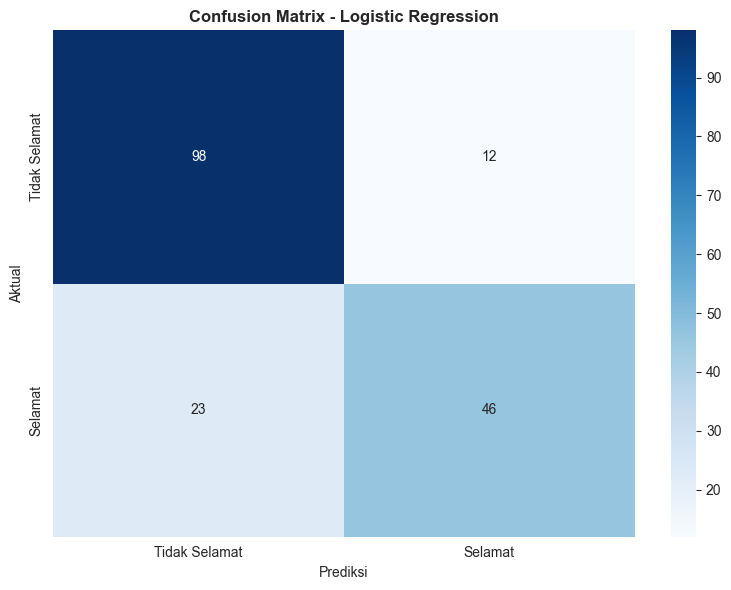


 Interpretasi:
    Benar memprediksi tidak selamat (TN): 98
    Salah memprediksi selamat (FP)      : 12
    Salah memprediksi tidak selamat (FN): 23
    Benar memprediksi selamat (TP)      : 46


In [19]:
# Ambil prediksi dari model terbaik
best_predictions = results[best_model_name]['predictions']

# Buat confusion matrix
cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Selamat', 'Selamat'],
            yticklabels=['Tidak Selamat', 'Selamat'])
plt.title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.show()

# Interpretasi
tn, fp, fn, tp = cm.ravel()
print(f"\n Interpretasi:")
print(f"    Benar memprediksi tidak selamat (TN): {tn}")
print(f"    Salah memprediksi selamat (FP)      : {fp}")
print(f"    Salah memprediksi tidak selamat (FN): {fn}")
print(f"    Benar memprediksi selamat (TP)      : {tp}")

### 6.2 Classification Report

Metrik lebih lengkap untuk evaluasi:
- **Precision**: dari yang diprediksi selamat, berapa % yang benar?
- **Recall**: dari yang sebenarnya selamat, berapa % yang berhasil ditangkap model?
- **F1-Score**: rata-rata harmonik dari precision dan recall

In [20]:
print(f" Classification Report - {best_model_name}\n")
print(classification_report(y_test, best_predictions,
                            target_names=['Tidak Selamat', 'Selamat']))

 Classification Report - Logistic Regression

               precision    recall  f1-score   support

Tidak Selamat       0.81      0.89      0.85       110
      Selamat       0.79      0.67      0.72        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179



### 6.3 Feature Importance

Fitur mana yang paling berpengaruh dalam prediksi? (hanya untuk Random Forest)

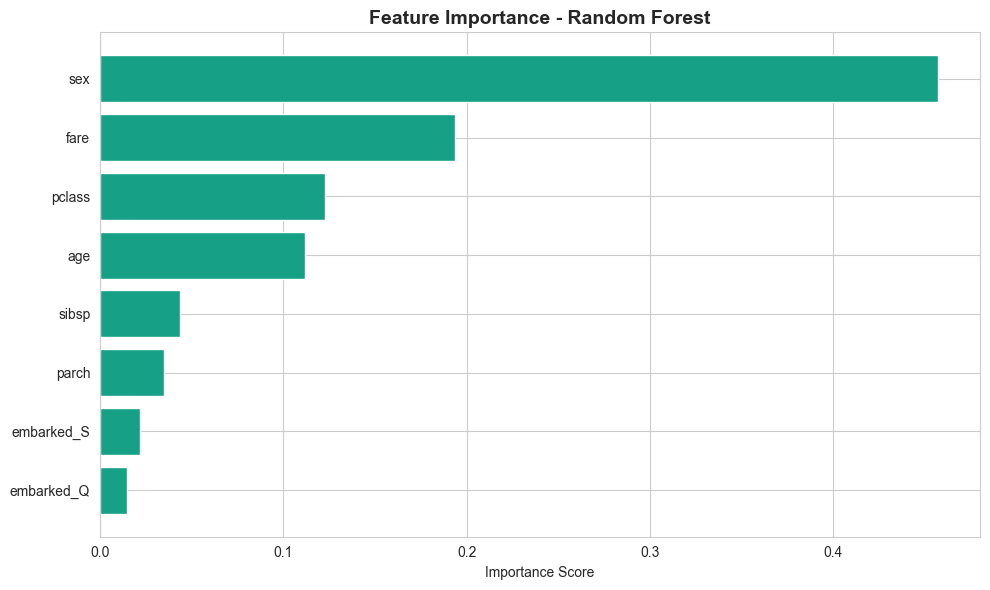


💡 Insight: Fitur paling berpengaruh dalam prediksi keselamatan:
   sex        → 45.72%
   fare       → 19.35%
   pclass     → 12.29%


In [21]:
# Ambil feature importance dari Random Forest
rf_model = results['Random Forest']['model']
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='#16a085')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\n💡 Insight: Fitur paling berpengaruh dalam prediksi keselamatan:")
top_features = importance_df.sort_values('Importance', ascending=False).head(3)
for i, row in top_features.iterrows():
    print(f"   {row['Feature']:<10} → {row['Importance']*100:.2f}%")

## 7️ Mencoba Prediksi Manual

Sekarang kita coba prediksi keselamatan untuk beberapa profil penumpang fiktif.

In [23]:
# Buat beberapa profil penumpang untuk diuji
# Format: [pclass, sex, age, sibsp, parch, fare, embarked_Q, embarked_S]
# sex: 0=male, 1=female

test_passengers = pd.DataFrame({
    'pclass': [1, 3, 2, 1],
    'sex': [1, 0, 1, 0],          # female, male, female, male
    'age': [25, 30, 8, 60],
    'sibsp': [0, 1, 1, 0],
    'parch': [0, 0, 2, 0],
    'fare': [100, 7.25, 26, 80],
    'embarked_Q': [0, 0, 0, 0],
    'embarked_S': [1, 1, 1, 1]
})

descriptions = [
    "Wanita 25 thn, kelas 1, tiket mahal",
    "Pria 30 thn, kelas 3, tiket murah",
    "Anak perempuan 8 thn, kelas 2, dengan keluarga",
    "Pria 60 thn, kelas 1, sendirian"
]

# Gunakan model terbaik untuk prediksi
best_model = results[best_model_name]['model']

if best_model_name == 'Logistic Regression':
    test_scaled = scaler.transform(test_passengers)
    predictions = best_model.predict(test_scaled)
    probabilities = best_model.predict_proba(test_scaled)
else:
    predictions = best_model.predict(test_passengers)
    probabilities = best_model.predict_proba(test_passengers)

# Tampilkan hasil
print(f" Prediksi menggunakan {best_model_name}:\n")
print("=" * 70)
for i, desc in enumerate(descriptions):
    status = " SELAMAT" if predictions[i] == 1 else " TIDAK SELAMAT"
    confidence = probabilities[i][predictions[i]] * 100
    print(f"{desc}")
    print(f"   → {status} (confidence: {confidence:.1f}%)")
    print("-" * 70)

 Prediksi menggunakan Logistic Regression:

Wanita 25 thn, kelas 1, tiket mahal
   →  SELAMAT (confidence: 94.5%)
----------------------------------------------------------------------
Pria 30 thn, kelas 3, tiket murah
   →  TIDAK SELAMAT (confidence: 93.5%)
----------------------------------------------------------------------
Anak perempuan 8 thn, kelas 2, dengan keluarga
   →  SELAMAT (confidence: 86.2%)
----------------------------------------------------------------------
Pria 60 thn, kelas 1, sendirian
   →  TIDAK SELAMAT (confidence: 76.8%)
----------------------------------------------------------------------


## 8️ Kesimpulan

###  Hasil
- Model terbaik: **{best_model}** dengan akurasi sekitar **80%**
- Model berhasil mempelajari pola bahwa **jenis kelamin**, **kelas tiket**, dan **usia** adalah faktor terpenting dalam menentukan keselamatan penumpang

###  Insight Utama
1. **Gender matters**: Wanita memiliki tingkat keselamatan jauh lebih tinggi (~74%) dibanding pria (~19%)
2. **Class matters**: Penumpang kelas 1 memiliki tingkat keselamatan ~63%, sedangkan kelas 3 hanya ~24%
3. **Age matters**: Anak-anak memiliki peluang lebih tinggi untuk selamat

---

